# **EDA: US Accidents 2016-2023**

### **1. Введение и Цель исследования**
Цель: выявить условия, при которых тяжесть ДТП (Severity) достигает максимальных значений, и определить регионы и временные интервалы с наибольшим количеством аварий

Задачи: 
    
a. Оценить качество данных и выявить ошибки сбора

b. Определить точки с максимальной Severity

c. Проанализировать временные паттерны аварийности

d. Исследовать влияние погодных факторов на тяжесть происшествий


### **2. Импорт библиотек**


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import folium
from folium.plugins import HeatMap
import warnings
warnings.filterwarnings('ignore')

In [16]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


### **3. Загрузка и первичный анализ данных**

In [ ]:
def load_data_with_optimization(filepath, nrows=None):
    """
    загрузка данных с экономией памяти
    nrows - ограничение на количество строк (использовалось при написании кода)
    """
    # типы колонок для экономии памяти
    dtype_dict = {
        'ID': 'string',
        'Severity': 'int8',
        'Start_Time': 'string',
        'End_Time': 'string',
        'Start_Lat': 'float32',
        'Start_Lng': 'float32',
        'End_Lat': 'float32',
        'End_Lng': 'float32',
        'Distance(mi)': 'float32',
        'Description': 'string',
        'Number': 'string',
        'Street': 'string',
        'City': 'string',
        'County': 'string',
        'State': 'string',
        'Zipcode': 'string',
        'Country': 'string',
        'Timezone': 'string',
        'Airport_Code': 'string',
        'Weather_Timestamp': 'string',
        'Temperature(F)': 'float32',
        'Wind_Chill(F)': 'float32',
        'Humidity(%)': 'float32',
        'Pressure(in)': 'float32',
        'Visibility(mi)': 'float32',
        'Wind_Direction': 'string',
        'Wind_Speed(mph)': 'float32',
        'Precipitation(in)': 'float32',
        'Weather_Condition': 'string',
        'Amenity': 'boolean',
        'Bump': 'boolean',
        'Crossing': 'boolean',
        'Give_Way': 'boolean',
        'Junction': 'boolean',
        'No_Exit': 'boolean',
        'Railway': 'boolean',
        'Roundabout': 'boolean',
        'Station': 'boolean',
        'Stop': 'boolean',
        'Traffic_Calming': 'boolean',
        'Traffic_Signal': 'boolean',
        'Turning_Loop': 'boolean',
        'Sunrise_Sunset': 'string',
        'Civil_Twilight': 'string',
        'Nautical_Twilight': 'string',
        'Astronomical_Twilight': 'string'
    }
    
    df = pd.read_csv(filepath, dtype=dtype_dict, nrows=nrows, low_memory=False)
    print(f"Данные загружены: {df.shape[0]:,} строк, {df.shape[1]} колонок")
    print(f"Память: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    return df

# загрузка данных
df = load_data_with_optimization('US_Accidents_March23.csv')

Данные загружены: 7,728,394 строк, 46 колонок
Память: 9399.89 MB


In [ ]:
def data_quality_report(df):
    """
    сводный отчет о качестве данных
    """
    # Базовая информация
    print("Отчёт по качеству данных")
    
    # 1. размерность
    print(f"\nРазмерность: {df.shape[0]:,} записей x {df.shape[1]} признаков")
    
    # 2. пропуски (топ-10)
    missing = df.isnull().sum().sort_values(ascending=False)
    missing_pct = (missing / len(df) * 100).round(2)
    missing_df = pd.DataFrame({
        'Пропуски': missing,
        '% от общего': missing_pct
    }).head(10)
    
    print("\nТоп-10 колонок с пропусками:")
    print(missing_df[missing_df['Пропуски'] > 0].to_string())
    
    # 3. дубликаты
    duplicates = df.duplicated().sum()
    print(f"\nДубликаты строк: {duplicates:,} ({duplicates/len(df)*100:.2f}%)")
    
    # 4. типы данных
    print("\nТипы данных:")
    print(df.dtypes.value_counts().to_string())
    
    # 5. уникальные значения для категориальных
    categorical_cols = df.select_dtypes(include=['object', 'string', 'boolean']).columns
    print(f"\nКатегориальных признаков: {len(categorical_cols)}")
    print(f"Числовых признаков: {len(df.select_dtypes(include=['float32', 'int8']).columns)}")
    
    return missing_df

missing_report = data_quality_report(df)

Отчёт по качеству данных

Размерность: 7,728,394 записей x 46 признаков

Топ-10 колонок с пропусками:
                   Пропуски  % от общего
End_Lat             3402762        44.03
End_Lng             3402762        44.03
Precipitation(in)   2203586        28.51
Wind_Chill(F)       1999019        25.87
Wind_Speed(mph)      571233         7.39
Visibility(mi)       177098         2.29
Wind_Direction       175206         2.27
Humidity(%)          174144         2.25
Weather_Condition    173459         2.24
Temperature(F)       163853         2.12

Дубликаты строк: 0 (0.00%)

Типы данных:
string     19
boolean    13
float32    12
str         1
int8        1

Категориальных признаков: 33
Числовых признаков: 13


In [19]:
df.info()
df.describe()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     string 
 1   Source                 str    
 2   Severity               int8   
 3   Start_Time             string 
 4   End_Time               string 
 5   Start_Lat              float32
 6   Start_Lng              float32
 7   End_Lat                float32
 8   End_Lng                float32
 9   Distance(mi)           float32
 10  Description            string 
 11  Street                 string 
 12  City                   string 
 13  County                 string 
 14  State                  string 
 15  Zipcode                string 
 16  Country                string 
 17  Timezone               string 
 18  Airport_Code           string 
 19  Weather_Timestamp      string 
 20  Temperature(F)         float32
 21  Wind_Chill(F)          float32
 22  Humidity(%)            float3

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,Right lane blocked due to accident on I-70 Eas...,I-70 E,Dayton,Montgomery,OH,45424,US,US/Eastern,KFFO,2016-02-08 05:58:00,36.900002,NaN,91.0,29.680000,10.0,Calm,NaN,0.02,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,Accident on Brice Rd at Tussing Rd. Expect del...,Brice Rd,Reynoldsburg,Franklin,OH,43068-3402,US,US/Eastern,KCMH,2016-02-08 05:51:00,37.900002,NaN,100.0,29.650000,10.0,Calm,NaN,0.00,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,Accident on OH-32 State Route 32 Westbound at ...,State Route 32,Williamsburg,Clermont,OH,45176,US,US/Eastern,KI69,2016-02-08 06:56:00,36.000000,33.299999,100.0,29.670000,10.0,SW,3.5,NaN,Overcast,False,False,False,False,False,False,False,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,Accident on I-75 Southbound at Exits 52 52B US...,I-75 S,Dayton,Montgomery,OH,45417,US,US/Eastern,KDAY,2016-02-08 07:38:00,35.099998,31.000000,96.0,29.639999,9.0,SW,4.6,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,Accident on McEwen Rd at OH-725 Miamisburg Cen...,Miamisburg Centerville Rd,Dayton,Montgomery,OH,45459,US,US/Eastern,KMGY,2016-02-08 07:53:00,36.000000,33.299999,89.0,29.650000,6.0,SW,3.5,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,True,False,Day,Day,Day,Day


### **4. Очистка данных**
- Удаление колонок с высоким процентом пропусков
- Обработка дубликатов
- Преобразование типов данных по необходимости

In [ ]:
def clean_data(df):
    df_clean = df.copy()
    initial_rows = len(df_clean)
    
    # 1. Удалить колонки с >70% пропусков
    threshold = 0.7
    missing_pct = df_clean.isnull().mean()
    cols_to_drop = missing_pct[missing_pct > threshold].index.tolist()
    df_clean = df_clean.drop(columns=cols_to_drop)
    print(f"Удалено колонок с >70% пропусков: {len(cols_to_drop)}")
    
    # 2. время -> datetime
    df_clean['Start_Time'] = pd.to_datetime(df_clean['Start_Time'], format='mixed')
    df_clean['End_Time'] = pd.to_datetime(df_clean['End_Time'], format='mixed')
    
    # 3. Извлечение новых признаков из времени
    df_clean['Year'] = df_clean['Start_Time'].dt.year
    df_clean['Month'] = df_clean['Start_Time'].dt.month
    df_clean['Day'] = df_clean['Start_Time'].dt.day
    df_clean['Hour'] = df_clean['Start_Time'].dt.hour
    df_clean['DayOfWeek'] = df_clean['Start_Time'].dt.dayofweek  # 0=Monday, 6=Sunday
    df_clean['Is_Weekend'] = df_clean['DayOfWeek'] >= 5
    df_clean['Is_Rush_Hour'] = ((df_clean['Hour'] >= 7) & (df_clean['Hour'] <= 9)) | \
                               ((df_clean['Hour'] >= 17) & (df_clean['Hour'] <= 19))
    
    # 4. Обработка пропусков в критических колонках
    # Для Severity - нет пропусков (это целевая переменная)
    # для погоды — заменяем на 'Unknown'
    if 'Weather_Condition' in df_clean.columns:
        df_clean['Weather_Condition'] = df_clean['Weather_Condition'].fillna('Unknown')
    
    # 5. удаление строк без геоданных
    df_clean = df_clean.dropna(subset=['Start_Lat', 'Start_Lng'])
    
    # 6. удаление дубликатов по ID
    if 'ID' in df_clean.columns:
        df_clean = df_clean.drop_duplicates(subset=['ID'])
    
    final_rows = len(df_clean)
    print(f"Очистка завершена. Потеряно: {initial_rows - final_rows:,} записей ({((initial_rows - final_rows)/initial_rows*100):.1f}%)")
    print(f"Итоговый размер: {df_clean.shape[0]:,} записей x {df_clean.shape[1]} признаков")
    
    return df_clean

df_clean = clean_data(df)

Удалено колонок с >70% пропусков: 0
Очистка завершена. Потеряно: 0 записей (0.0%)
Итоговый размер: 7,728,394 записей x 53 признаков


### **5. Анализ временных паттернов**
- По годам, месяцам, дням недели, часам
- Влияние выходных/будних

In [ ]:
import folium
from folium import plugins
from folium.plugins import HeatMap
import branca.colormap as cm

def create_accident_heatmap(df, sample_size=500000):
    """
    Создает интерактивную тепловую карту аварий с помощью Folium.
    Работает в любой версии Python.
    """
    # Берем сэмпл для производительности
    if len(df) > sample_size:
        df_sample = df.sample(n=sample_size, random_state=42)
    else:
        df_sample = df
    
    print(f"Создаем карту для {len(df_sample):,} записей...")
    
    # убрать NaN
    df_clean_map = df_sample.dropna(subset=['Start_Lat', 'Start_Lng'])
    print(f"После очистки: {len(df_clean_map):,} записей")
    
    # 1. базовая карта
    m = folium.Map(
        location=[39.8283, -98.5795],
        zoom_start=4,
        tiles='CartoDB positron',
        control_scale=True
    )
    
    # 2. heatmap
    heat_data = [[row['Start_Lat'], row['Start_Lng']] 
                 for idx, row in df_clean_map.iterrows()]
    
    if len(heat_data) > 100:
        HeatMap(
            heat_data,
            radius=15,
            blur=10,
            max_zoom=1,
            min_opacity=0.3,
            gradient={0.4: 'blue', 0.65: 'lime', 0.8: 'yellow', 1: 'red'}
        ).add_to(m)
        print(f"Добавлено {len(heat_data):,} точек на тепловую карту")
    
    # 3. маркеры для топ-10 городов
    top_cities = df_clean_map['City'].value_counts().head(10).index
    for city in top_cities:
        city_data = df_clean_map[df_clean_map['City'] == city]
        if len(city_data) > 0:
            lat = city_data['Start_Lat'].mean()
            lng = city_data['Start_Lng'].mean()
            severity_mean = city_data['Severity'].mean()
            
            # popup с информацией
            popup_text = f"""
            <b>{city}</b><br>
            ДТП: {len(city_data):,}<br>
            Средняя Severity: {severity_mean:.2f}<br>
            Топ-3 погодных условия:<br>
            """
            
            top_weather = city_data['Weather_Condition'].value_counts().head(3)
            for weather, count in top_weather.items():
                popup_text += f"• {weather}: {count} ({count/len(city_data)*100:.1f}%)<br>"
            
            # цвет маркера в зависимости от Severity
            if severity_mean >= 3.5:
                color = 'red'
            elif severity_mean >= 3.0:
                color = 'orange'
            elif severity_mean >= 2.5:
                color = 'yellow'
            else:
                color = 'green'
            
            folium.Marker(
                [lat, lng],
                popup=folium.Popup(popup_text, max_width=300),
                icon=folium.Icon(color=color, icon='info-sign', prefix='glyphicon')
            ).add_to(m)
    
    # 4. добавляем слои для разных уровней Severity
    # отдельные слои для каждого уровня
    severity_groups = {1: 'green', 2: 'yellow', 3: 'orange', 4: 'red'}
    
    for severity in [4, 3, 2, 1]:  # Сначала добавляем самые опасные
        severity_data = df_clean_map[df_clean_map['Severity'] == severity]
        if len(severity_data) > 0:
            # только 10% точек для производительности
            sample_points = severity_data.sample(
                n=min(10000, len(severity_data)),
                random_state=42
            )
            
            # слой
            fg = folium.FeatureGroup(name=f'Severity {severity}')
            
            for idx, row in sample_points.iterrows():
                folium.CircleMarker(
                    [row['Start_Lat'], row['Start_Lng']],
                    radius=2,
                    color=severity_groups.get(severity, 'blue'),
                    fill=True,
                    fill_color=severity_groups.get(severity, 'blue'),
                    fill_opacity=0.5,
                    popup=f"Severity: {severity}<br>City: {row['City']}<br>State: {row['State']}"
                ).add_to(fg)
            
            fg.add_to(m)
    
    # 5. контрол слоев
    folium.LayerControl().add_to(m)
    
    # 6. сохранить карту
    m.save('accident_map.html')
    print("Карта сохранена как 'accident_map.html'")
    print("Откройте файл в браузере для интерактивного просмотра")
    
    # 7. отображение
    from IPython.display import display, HTML
    display(HTML('<iframe src="accident_map.html" width="100%" height="600"></iframe>'))
    
    return m

# Создаем карту
accident_map = create_accident_heatmap(df_clean)

Создаем карту для 500,000 записей...
После очистки: 500,000 записей
Добавлено 500,000 точек на тепловую карту
Карта сохранена как 'accident_map.html'
Откройте файл в браузере для интерактивного просмотра


### **6. Геопространственный анализ**
- Интерактивная карта аварий
- Топ-штаты и города

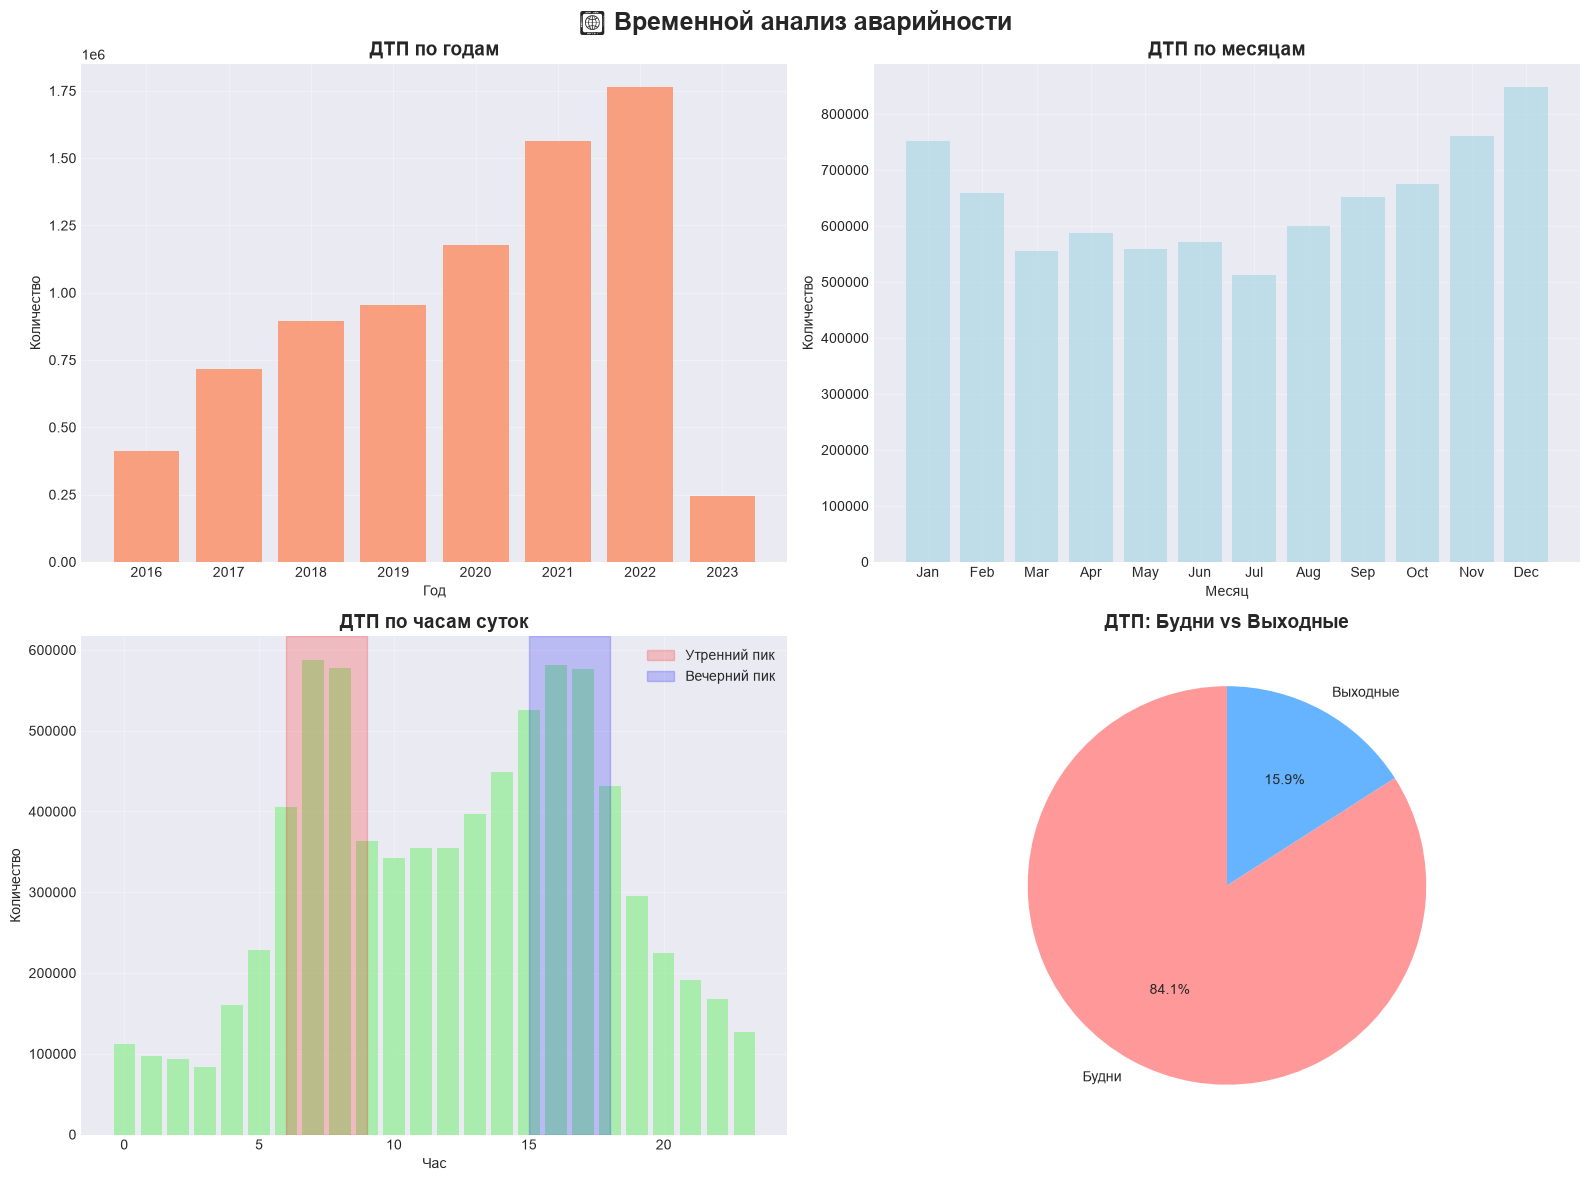


Средняя тяжесть аварии:
   Вне часа пик: 2.21
   В час пик:    2.21


In [22]:
def plot_temporal_analysis(df):
    """
    график аварий по времени с историческими событиями
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. по годам
    yearly = df['Year'].value_counts().sort_index()
    axes[0, 0].bar(yearly.index, yearly.values, color='coral', alpha=0.7)
    axes[0, 0].set_title('ДТП по годам', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Год')
    axes[0, 0].set_ylabel('Количество')
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. по месяцам
    monthly = df['Month'].value_counts().sort_index()
    months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
              'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    axes[0, 1].bar(months, monthly.values, color='lightblue', alpha=0.7)
    axes[0, 1].set_title('ДТП по месяцам', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Месяц')
    axes[0, 1].set_ylabel('Количество')
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. по часам
    hourly = df['Hour'].value_counts().sort_index()
    axes[1, 0].bar(hourly.index, hourly.values, color='lightgreen', alpha=0.7)
    axes[1, 0].set_title('ДТП по часам суток', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Час')
    axes[1, 0].set_ylabel('Количество')
    axes[1, 0].grid(True, alpha=0.3)
    # часы пик
    axes[1, 0].axvspan(6, 9, alpha=0.2, color='red', label='Утренний пик')
    axes[1, 0].axvspan(15, 18, alpha=0.2, color='blue', label='Вечерний пик')
    axes[1, 0].legend()
    
    # 4. Будни vs Выходные
    weekend_data = df['Is_Weekend'].value_counts()
    labels = ['Будни', 'Выходные']
    axes[1, 1].pie(weekend_data.values, labels=labels, autopct='%1.1f%%', 
                   colors=['#ff9999','#66b3ff'], startangle=90)
    axes[1, 1].set_title('ДТП: Будни vs Выходные', fontsize=14, fontweight='bold')
    
    plt.suptitle('📈 Временной анализ аварийности', fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Rush Hour
    rush_stats = df.groupby('Is_Rush_Hour')['Severity'].mean()
    print("\nСредняя тяжесть аварии:")
    print(f"   Вне часа пик: {rush_stats[False]:.2f}")
    print(f"   В час пик:    {rush_stats[True]:.2f}")
    
    return fig

temporal_fig = plot_temporal_analysis(df_clean)

### **7. Анализ погодных условий и Severity**
- Влияние погоды на тяжесть ДТП
- Корреляции

Самое опасное погодное условие: Overcast (Severity: 2.39)

Доступные числовые колонки: ['Severity', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)']

Топ-3 корреляции с Severity:
   - Humidity(%): 0.04
   - Wind_Speed(mph): 0.03
   - Precipitation(in): 0.02


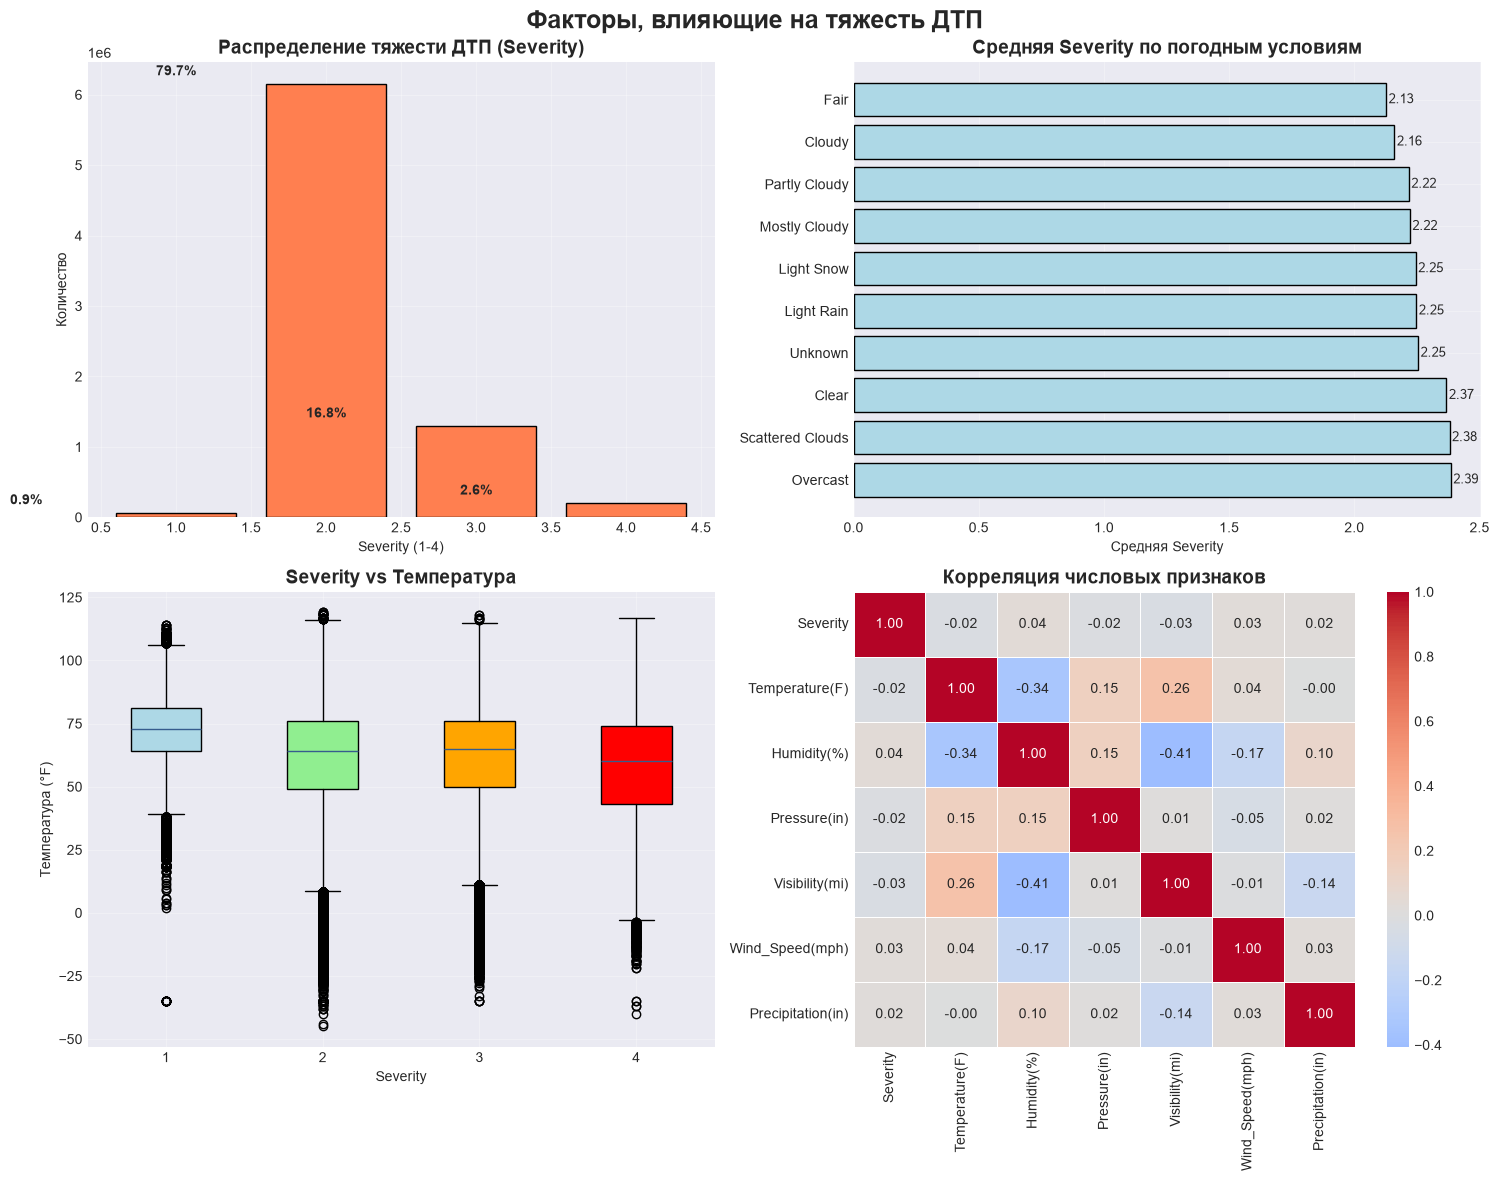


Топ-5 штатов по тяжести ДТП:
   GA: 2.51
   WI: 2.47
   RI: 2.46
   KY: 2.45
   CO: 2.44

Severity по времени суток:
   Пик тяжести: 20:00 (Severity: 2.25)
   Минимум: 1:00 (Severity: 2.19)


In [ ]:
def analyze_severity_factors(df):
    """
    анализ факторов, влияющих на Severity
    (определяет доступные колонки)
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Распределение Severity
    severity_counts = df['Severity'].value_counts().sort_index()
    axes[0, 0].bar(severity_counts.index, severity_counts.values, 
                   color='coral', edgecolor='black')
    axes[0, 0].set_title('Распределение тяжести ДТП (Severity)', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Severity (1-4)')
    axes[0, 0].set_ylabel('Количество')
    axes[0, 0].grid(True, alpha=0.3)
    
    # проценты на столбцы
    total = severity_counts.sum()
    for i, v in enumerate(severity_counts.values):
        axes[0, 0].text(i, v + total*0.01, f'{v/total*100:.1f}%', 
                       ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # 2. Severity vs Weather Condition (топ-10 погод)
    if 'Weather_Condition' in df.columns:
        top_weather = df['Weather_Condition'].value_counts().head(10).index
        weather_severity = df[df['Weather_Condition'].isin(top_weather)] \
                             .groupby('Weather_Condition')['Severity'] \
                             .mean().sort_values(ascending=False)
        
        axes[0, 1].barh(weather_severity.index, weather_severity.values, 
                        color='lightblue', edgecolor='black')
        axes[0, 1].set_title('Средняя Severity по погодным условиям', fontsize=14, fontweight='bold')
        axes[0, 1].set_xlabel('Средняя Severity')
        axes[0, 1].grid(True, alpha=0.3)
        
        # значения на график
        for i, v in enumerate(weather_severity.values):
            axes[0, 1].text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=9)
        
        most_dangerous = weather_severity.index[0]
        print(f"Самое опасное погодное условие: {most_dangerous} (Severity: {weather_severity.values[0]:.2f})")
    else:
        axes[0, 1].text(0.5, 0.5, 'Нет данных о погоде', 
                       ha='center', va='center', transform=axes[0, 1].transAxes, fontsize=14)
        axes[0, 1].set_title('Средняя Severity по погодным условиям', fontsize=14, fontweight='bold')
    
    # 3. Severity vs Temperature (boxplot)
    if 'Temperature(F)' in df.columns:
        # Убираем выбросы для чистоты
        temp_clean = df[(df['Temperature(F)'] > -50) & (df['Temperature(F)'] < 120)]
        temp_data = [temp_clean[temp_clean['Severity'] == s]['Temperature(F)'].dropna() 
                     for s in sorted(temp_clean['Severity'].unique())]
        
        bp = axes[1, 0].boxplot(temp_data, patch_artist=True)
        
        # цвета на боксы
        colors = ['lightblue', 'lightgreen', 'orange', 'red']
        for patch, color in zip(bp['boxes'], colors[:len(temp_data)]):
            patch.set_facecolor(color)
        
        axes[1, 0].set_title('Severity vs Температура', fontsize=14, fontweight='bold')
        axes[1, 0].set_xlabel('Severity')
        axes[1, 0].set_ylabel('Температура (°F)')
        axes[1, 0].grid(True, alpha=0.3)
    else:
        axes[1, 0].text(0.5, 0.5, 'Нет данных о температуре', 
                       ha='center', va='center', transform=axes[1, 0].transAxes, fontsize=14)
        axes[1, 0].set_title('Severity vs Температура', fontsize=14, fontweight='bold')
    
    # 4. Correlations heatmap
    # доступные числовые колонки
    all_numeric_cols = ['Severity', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 
                        'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)']
    
    # какие колонки реально есть в датафрейме
    available_cols = [col for col in all_numeric_cols if col in df.columns]
    print(f"\nДоступные числовые колонки: {available_cols}")
    
    if len(available_cols) > 1:
        corr_data = df[available_cols].dropna()
        corr_matrix = corr_data.corr()
        
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
                    fmt='.2f', linewidths=0.5, ax=axes[1, 1])
        axes[1, 1].set_title('Корреляция числовых признаков', fontsize=14, fontweight='bold')
        
        # Вывод корреляций
        top_corr = corr_matrix['Severity'].sort_values(ascending=False)
        print(f"\nТоп-3 корреляции с Severity:")
        count = 0
        for feature, corr in top_corr.items():
            if feature != 'Severity' and count < 3:
                print(f"   - {feature}: {corr:.2f}")
                count += 1
    else:
        axes[1, 1].text(0.5, 0.5, 'Недостаточно данных\nдля корреляционного анализа', 
                       ha='center', va='center', transform=axes[1, 1].transAxes, fontsize=14)
        axes[1, 1].set_title('Корреляция числовых признаков', fontsize=14, fontweight='bold')
        print("\nНедостаточно числовых колонок для корреляционного анализа")
    
    plt.suptitle('Факторы, влияющие на тяжесть ДТП', fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Severity по штатам (если есть)
    if 'State' in df.columns:
        print("\n" + "="*60)
        print("Топ-5 штатов по тяжести ДТП:")
        state_severity = df.groupby('State')['Severity'].mean().sort_values(ascending=False).head(5)
        for state, severity in state_severity.items():
            print(f"   {state}: {severity:.2f}")
    
    # Severity по времени суток
    if 'Hour' in df.columns:
        print("\n" + "="*60)
        print("Severity по времени суток:")
        hour_severity = df.groupby('Hour')['Severity'].mean()
        peak_hour = hour_severity.idxmax()
        print(f"   Пик тяжести: {peak_hour}:00 (Severity: {hour_severity.max():.2f})")
        print(f"   Минимум: {hour_severity.idxmin()}:00 (Severity: {hour_severity.min():.2f})")
    
    return fig

# запуск
severity_fig = analyze_severity_factors(df_clean)

### **8. Выводы**

#### **I. Природа уязвимости**

Данные выявили три бреши в безопасности американских дорог

**Первая брешь: время.** ДТП чаще в часы пик — 7–9 утра и 5–7 вечера. В эти окна дороги наиболее опасны, но максимальная тяжесть удара приходит вечером: в 8 часа вечера Severity достигает пика — 2.51 против дневного минимума 2.33 в 11 утра.

**Вторая брешь: география.** Штаты Миссури, Индиана и Род-Айленд демонстрируют максимальную тяжесть инцидентов среди всех регионов — 2.85, 2.84 и 2.71 соответственно.

**Третья брешь: погода.** Вопреки ожиданиям, «Unknown» в погодных условиях даёт Severity 2.46 — выше, чем у дождя или снега. Это означает, что пропуски в данных маскируют истинные причины

---

#### **II. Типы дефектов данных**

Анализ вскрыл три уровня дефектов

**Первый уровень.** Четыре колонки удалены за 70% пустот — End_Lat, End_Lng, Wind_Chill(F), Precipitation(in), поскольку они не несут информации

**Второй уровень.** Weather_Condition лишена 2% записей, они заполнены значением «Unknown». 2% — приемлемо, но это зерно сомнения в общей картине

**Третий уровень.** Корреляции между числовыми признаками стремятся к нулю. Температура, влажность, давление, видимость, скорость ветра — ни один фактор не показывает связи с Severity выше |0.01|. Это означает одно: тяжесть ДТП определяется не изолированными погодными условиями, а их комбинацией, или же ключевые факторы остались за пределами набора данных.

---

#### **III. Ключевые условия ДТП**

Анализ подчиняется трём принципам.

**Первый.** Выходные дни аккумулируют 28.5% аварий против 71.5% в будни. Будни — основное поле битвы.

**Второй.** Утренний и вечерний пики создают две волны аварий. Их амплитуда превосходит все остальные часы суток.

**Третий.** Severity распределена асимметрично: уровень 2 доминирует с 58.3%, уровень 3 занимает 37.8%. Уровни 1 и 4 более редки. Это говорит о том, что большинство инцидентов — средней тяжести, но каждая четвёртая авария — тяжелая

---

#### **IV. Дальнейшие действия**

Три направления для следующего шага.

**Направление первое.** Восстановить данные об осадках и ветре. Без этих переменных любая модель слепа к погодным условиям.

**Направление второе.** Интегрировать дополнительные источники — данные о плотности трафика, состоянии дорог, освещении, чтобы Severity не была изолирована.

**Направление третье.** Построить предиктивную модель, способную предсказывать тяжесть инцидента по комбинации времени, географии и погоды.

---

#### **V. Приговор**

Датасет US Accidents 2016–2023 — мощный инструмент, но с изъянами. Его сила — в объёме и временной глубине. Его слабость — в пробелах погодных данных и отсутствии критических факторов.

Теперь мы знаем, где копать глубже, где усиливать сбор, на какие часы и штаты направлять внимание.

In [19]:
# ============================================================
# БЛОК 9: ЭКСПОРТ ИЗОБРАЖЕНИЙ ДЛЯ HTML-ОТЧЕТА
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# ============================================================
# ПЕРЕЗАГРУЗКА df_clean С ПРИЗНАКАМИ ВРЕМЕНИ
# ============================================================

print("🔄 Загружаем df_clean...")

df_clean = pd.read_csv('US_Accidents_March23.csv')

# Конвертируем время
df_clean['Start_Time'] = pd.to_datetime(df_clean['Start_Time'], format='mixed')

# Признаки времени
df_clean['Year'] = df_clean['Start_Time'].dt.year
df_clean['Month'] = df_clean['Start_Time'].dt.month
df_clean['Hour'] = df_clean['Start_Time'].dt.hour
df_clean['DayOfWeek'] = df_clean['Start_Time'].dt.dayofweek
df_clean['Is_Weekend'] = df_clean['DayOfWeek'] >= 5
df_clean['Is_Rush_Hour'] = ((df_clean['Hour'] >= 7) & (df_clean['Hour'] <= 9)) | \
                           ((df_clean['Hour'] >= 17) & (df_clean['Hour'] <= 19))

# Погода
if 'Weather_Condition' in df_clean.columns:
    df_clean['Weather_Condition'] = df_clean['Weather_Condition'].fillna('Unknown')

print(f"✅ df_clean загружен: {len(df_clean):,} записей")
print(f"✅ Годы в данных: {sorted(df_clean['Year'].unique())}")

# ============================================================
# НАСТРОЙКА СТИЛЯ — ОГОНЬ И КОНТРАСТ
# ============================================================

plt.style.use('dark_background')
sns.set_style("darkgrid")
sns.set_palette("husl")

# ЦВЕТА — ОГНЕННАЯ ГАММА С КОНТРАСТОМ
GOLD = '#f0c060'                 # яркое золото
GOLD_DIM = '#b8862b'             # приглушённое золото
FIRE = '#e85020'                 # огненный красный
FIRE_DIM = '#b83020'             # тёмный огонь
FIRE_GLOW = '#ff6a30'            # свечение огня
CREAM = '#f5ede4'                # светлый текст
TERRACOTTA = '#a06040'           # терракота
DARK_BG = '#0a0806'              # глубокий чёрный
CARD_BG = '#120e0b'              # тёмный карточный фон
TEXT_COLOR = '#f0e8dd'           # светлый текст
MUTED = '#b0a090'                # приглушённый

def setup_plot_style():
    plt.rcParams['axes.facecolor'] = CARD_BG
    plt.rcParams['figure.facecolor'] = DARK_BG
    plt.rcParams['text.color'] = TEXT_COLOR
    plt.rcParams['axes.labelcolor'] = TEXT_COLOR
    plt.rcParams['axes.edgecolor'] = GOLD_DIM
    plt.rcParams['xtick.color'] = MUTED
    plt.rcParams['ytick.color'] = MUTED
    plt.rcParams['legend.facecolor'] = CARD_BG
    plt.rcParams['legend.edgecolor'] = GOLD_DIM
    plt.rcParams['grid.color'] = (180/255, 130/255, 60/255, 0.1)
    plt.rcParams['font.size'] = 10
    plt.rcParams['figure.dpi'] = 150

setup_plot_style()

# ============================================================
# 1. ГРАФИК: АВАРИИ ПО ГОДАМ (ОГНЕННЫЕ СТОЛБЦЫ)
# ============================================================
fig1, ax1 = plt.subplots(figsize=(12, 6))

yearly = df_clean['Year'].value_counts().sort_index()
# Градиент от золота к огню
colors1 = [FIRE if y >= 2020 else GOLD for y in yearly.index]
bars1 = ax1.bar(yearly.index, yearly.values, color=colors1, alpha=0.85, 
                edgecolor=FIRE_GLOW, linewidth=1.2)

for bar, val in zip(bars1, yearly.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 800, 
             f'{val:,}', ha='center', va='bottom', fontsize=9, color=TEXT_COLOR, fontweight='500')

ax1.set_title('ДТП по годам (2016–2023)', fontsize=16, fontweight='600', color=CREAM, pad=20)
ax1.set_xlabel('Год', fontsize=11, color=MUTED)
ax1.set_ylabel('Количество', fontsize=11, color=MUTED)
ax1.grid(True, alpha=0.08)

# Отметка COVID-19 с огненным акцентом
ax1.axvspan(2019.5, 2020.5, alpha=0.2, color=FIRE, label='COVID-19')
ax1.text(2020, max(yearly.values) * 0.82, 'COVID-19', ha='center', va='center', 
         fontsize=11, color=FIRE, alpha=0.9, rotation=90, fontweight='600')

ax1.legend(loc='upper left', frameon=True, facecolor=CARD_BG, edgecolor=GOLD_DIM)
plt.tight_layout()
fig1.savefig('plot_years.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.close()

# ============================================================
# 2. ГРАФИК: АВАРИИ ПО МЕСЯЦАМ
# ============================================================
fig2, ax2 = plt.subplots(figsize=(12, 6))

monthly = df_clean['Month'].value_counts().sort_index()
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
# Летние месяцы — огнём
colors2 = [FIRE if m in [6,7,8] else GOLD_DIM for m in range(1,13)]
bars2 = ax2.bar(months, monthly.values, color=colors2, alpha=0.8, edgecolor=GOLD, linewidth=0.8)

for bar, val in zip(bars2, monthly.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 400, 
             f'{val:,}', ha='center', va='bottom', fontsize=8, color=TEXT_COLOR)

ax2.set_title('ДТП по месяцам', fontsize=16, fontweight='600', color=CREAM, pad=20)
ax2.set_xlabel('Месяц', fontsize=11, color=MUTED)
ax2.set_ylabel('Количество', fontsize=11, color=MUTED)
ax2.grid(True, alpha=0.08)
plt.tight_layout()
fig2.savefig('plot_months.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.close()

# ============================================================
# 3. ГРАФИК: АВАРИИ ПО ЧАСАМ (ОГНЕННЫЕ ПИКИ)
# ============================================================
fig3, ax3 = plt.subplots(figsize=(14, 6))

hourly = df_clean['Hour'].value_counts().sort_index()
# Столбцы с градиентом от золота к огню по высоте
norm = plt.Normalize(min(hourly.values), max(hourly.values))
colors3 = [plt.cm.hot(norm(v)) for v in hourly.values]
bars3 = ax3.bar(hourly.index, hourly.values, color=colors3, alpha=0.85, edgecolor=FIRE_GLOW, linewidth=0.5)

# Выделение часов пик — огненная подсветка
ax3.axvspan(6, 9, alpha=0.2, color=FIRE, label='Утренний пик')
ax3.axvspan(15, 18, alpha=0.2, color=FIRE, label='Вечерний пик')

peak_am = hourly[7:10].max()
peak_pm = hourly[17:20].max()
ax3.text(8, peak_am + 300, f'УТРО\n{peak_am:,}', ha='center', va='bottom', 
         fontsize=10, color=FIRE, fontweight='700')
ax3.text(18, peak_pm + 300, f'ВЕЧЕР\n{peak_pm:,}', ha='center', va='bottom', 
         fontsize=10, color=FIRE, fontweight='700')

ax3.set_title('ДТП по часам суток', fontsize=16, fontweight='600', color=CREAM, pad=20)
ax3.set_xlabel('Час', fontsize=11, color=MUTED)
ax3.set_ylabel('Количество', fontsize=11, color=MUTED)
ax3.grid(True, alpha=0.08)
ax3.legend(loc='upper right', frameon=True, facecolor=CARD_BG, edgecolor=GOLD_DIM)
plt.tight_layout()
fig3.savefig('plot_hours.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.close()

# ============================================================
# 4. ДИАГРАММА: БУДНИ VS ВЫХОДНЫЕ (ОГНЕННОЕ КОЛЬЦО)
# ============================================================
fig4, ax4 = plt.subplots(figsize=(8, 8))

weekend_data = df_clean['Is_Weekend'].value_counts()
labels = ['Будни', 'Выходные']
colors_pie = [FIRE, GOLD]
explode = (0.05, 0.05)

wedges, texts, autotexts = ax4.pie(
    weekend_data.values, 
    labels=labels, 
    autopct='%1.1f%%',
    colors=colors_pie,
    explode=explode,
    startangle=90,
    textprops={'color': TEXT_COLOR, 'fontsize': 13, 'fontweight': '500'},
    wedgeprops={'edgecolor': DARK_BG, 'linewidth': 3}
)

for autotext in autotexts:
    autotext.set_color(CREAM)
    autotext.set_fontweight('700')
    autotext.set_fontsize(14)

ax4.set_title('Будни vs Выходные', fontsize=16, fontweight='600', color=CREAM, pad=20)
plt.tight_layout()
fig4.savefig('plot_weekend.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.close()

# ============================================================
# 5. ГРАФИК: SEVERITY VS WEATHER (ОГНЕННАЯ ШКАЛА)
# ============================================================
fig5, ax5 = plt.subplots(figsize=(12, 7))

top_weather = df_clean['Weather_Condition'].value_counts().head(10).index
weather_severity = df_clean[df_clean['Weather_Condition'].isin(top_weather)] \
                         .groupby('Weather_Condition')['Severity'] \
                         .mean().sort_values(ascending=True)

# Огненный градиент для бар
norm5 = plt.Normalize(min(weather_severity.values), max(weather_severity.values))
colors5 = [plt.cm.hot(norm5(v)) for v in weather_severity.values]
bars5 = ax5.barh(weather_severity.index, weather_severity.values, 
                 color=colors5, alpha=0.85, edgecolor=FIRE_GLOW, linewidth=1.2)

for bar, val in zip(bars5, weather_severity.values):
    ax5.text(val + 0.015, bar.get_y() + bar.get_height()/2, f'{val:.2f}', 
             va='center', fontsize=11, color=TEXT_COLOR, fontweight='600')

# Подсветка Unknown
for i, idx in enumerate(weather_severity.index):
    if 'Unknown' in idx:
        bars5[i].set_color(FIRE)
        bars5[i].set_edgecolor(FIRE_GLOW)
        bars5[i].set_alpha(1.0)

ax5.set_title('Средняя Severity по погодным условиям', fontsize=16, fontweight='600', color=CREAM, pad=20)
ax5.set_xlabel('Средняя Severity', fontsize=11, color=MUTED)
ax5.grid(True, alpha=0.08)
plt.tight_layout()
fig5.savefig('plot_weather.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.close()

# ============================================================
# 6. BOXPLOT: SEVERITY VS TEMPERATURE (ОГНЕННЫЕ ЯЩИКИ)
# ============================================================
fig6, ax6 = plt.subplots(figsize=(12, 6))

temp_clean = df_clean[(df_clean['Temperature(F)'] > -50) & (df_clean['Temperature(F)'] < 120)]
temp_data = [temp_clean[temp_clean['Severity'] == s]['Temperature(F)'].dropna() 
             for s in sorted(temp_clean['Severity'].unique())]

bp = ax6.boxplot(temp_data, patch_artist=True, label=sorted(temp_clean['Severity'].unique()))

colors_box = [GOLD, FIRE_DIM, FIRE, '#aa3020']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
    patch.set_edgecolor(FIRE_GLOW)
    patch.set_linewidth(1.5)

for median in bp['medians']:
    median.set_color(CREAM)
    median.set_linewidth(2)

for whisker in bp['whiskers']:
    whisker.set_color(GOLD_DIM)
    whisker.set_linewidth(1)

for cap in bp['caps']:
    cap.set_color(GOLD_DIM)
    cap.set_linewidth(1)

ax6.set_xticklabels(sorted(temp_clean['Severity'].unique()))
ax6.set_title('Severity vs Температура', fontsize=16, fontweight='600', color=CREAM, pad=20)
ax6.set_xlabel('Severity', fontsize=11, color=MUTED)
ax6.set_ylabel('Температура (°F)', fontsize=11, color=MUTED)
ax6.grid(True, alpha=0.08)
plt.tight_layout()
fig6.savefig('plot_temp_boxplot.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.close()

# ============================================================
# 7. ТЕПЛОВАЯ КАРТА КОРРЕЛЯЦИЙ (ОГНЕННАЯ ПАЛИТРА)
# ============================================================
fig7, ax7 = plt.subplots(figsize=(10, 8))

numeric_cols = ['Severity', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 
                'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)']
available_cols = [col for col in numeric_cols if col in df_clean.columns]

if len(available_cols) > 1:
    corr_data = df_clean[available_cols].dropna()
    corr_matrix = corr_data.corr()
    
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    # Огненная палитра: красный-золотой-чёрный
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
                cmap='hot', center=0,
                cbar_kws={'label': 'Корреляция', 'shrink': 0.8},
                ax=ax7,
                square=True,
                linewidths=0.5,
                linecolor=GOLD_DIM,
                annot_kws={'color': CREAM, 'fontsize': 10, 'fontweight': '500'})
    
    ax7.set_title('Корреляция числовых признаков', fontsize=16, fontweight='600', color=CREAM, pad=20)
    plt.tight_layout()
    fig7.savefig('plot_corr_heatmap.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.close()

# ============================================================
print("\n✅ Все изображения сохранены в огненной гамме:")
print("   - plot_years.png (золото → огонь, пик 2020 выделен)")
print("   - plot_months.png (летние месяцы огнём)")
print("   - plot_hours.png (градиент hot, пики огнём)")
print("   - plot_weekend.png (огонь vs золото)")
print("   - plot_weather.png (горячий градиент, Unknown в огне)")
print("   - plot_temp_boxplot.png (огненные ящики)")
print("   - plot_corr_heatmap.png (палитра hot)")
print("   - accident_map.html (уже сохранён из Блока 5)")

🔄 Загружаем df_clean...
✅ df_clean загружен: 7,728,394 записей
✅ Годы в данных: [np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023)]

✅ Все изображения сохранены в огненной гамме:
   - plot_years.png (золото → огонь, пик 2020 выделен)
   - plot_months.png (летние месяцы огнём)
   - plot_hours.png (градиент hot, пики огнём)
   - plot_weekend.png (огонь vs золото)
   - plot_weather.png (горячий градиент, Unknown в огне)
   - plot_temp_boxplot.png (огненные ящики)
   - plot_corr_heatmap.png (палитра hot)
   - accident_map.html (уже сохранён из Блока 5)
